# Electric Power Grid Stability Prediction
## Using Random Forest and Support Vector Machine (SVM)

This notebook implements machine learning models to predict electrical grid stability (stable vs. unstable) based on various system parameters.

**Key Models:**
- Random Forest: Ensemble method for handling non-linear patterns
- Support Vector Machine (SVM): Finds clear boundaries between classes

**Dataset Features:**
- tau1-tau4: Reaction time features (most important predictors)
- p1-p4: Power features
- g1-g4: Gamma features
- stab: Numerical stability value
- stabf: Target variable (stable/unstable)

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('Data_for_UCI_named.csv')

print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First Few Rows:")
print("="*80)
df.head()

Dataset Shape: (10000, 14)

First Few Rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.9591,3.0799,8.3810,9.7808,3.7631,-0.7826,-1.2574,-1.7231,0.6505,0.8596,0.8874,0.9580,0.0553,unstable
1,9.3041,4.9025,3.0475,1.3694,5.0678,-1.9401,-1.8727,-1.2550,0.4134,0.8624,0.5621,0.7818,-0.0060,stable
2,8.9717,8.8484,3.0465,1.2145,3.4052,-1.2075,-1.2772,-0.9205,0.1630,0.7667,0.8394,0.1099,0.0035,unstable
3,0.7164,7.6696,4.4866,2.3406,3.9638,-1.0275,-1.9389,-0.9974,0.4462,0.9767,0.9294,0.3627,0.0289,unstable
4,3.1341,7.6088,4.9438,9.8576,3.5258,-1.1255,-1.8460,-0.5543,0.7971,0.4554,0.6569,0.8209,0.0499,unstable


In [3]:
# Dataset information
print("Dataset Information:")
print("="*80)
df.info()
print("\n" + "="*80)
print("Statistical Summary:")
print("="*80)
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB

Statistical Summary:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5.2500,5.2500,5.2500,5.2500,3.7500,-1.2500,-1.2500,-1.2500,0.5250,0.5250,0.5250,0.5250,0.0157
std,2.7425,2.7425,2.7425,2.7426,0.7522,0.4330,0.4330,0.4330,0.2743,0.2743,0.2743,0.2743,0.0369
min,0.5008,0.5001,0.5008,0.5005,1.5826,-1.9999,-1.9999,-1.9999,0.0500,0.0501,0.0501,0.0500,-0.0808
25%,2.8749,2.8751,2.8755,2.8750,3.2183,-1.6249,-1.6250,-1.6250,0.2875,0.2876,0.2875,0.2875,-0.0156
50%,5.2500,5.2500,5.2500,5.2497,3.7510,-1.2500,-1.2500,-1.2500,0.5250,0.5250,0.5250,0.5250,0.0171
75%,7.6247,7.6249,7.6249,7.6248,4.2824,-0.8750,-0.8750,-0.8751,0.7624,0.7625,0.7624,0.7624,0.0449
max,9.9995,9.9998,9.9995,9.9994,5.8644,-0.5001,-0.5001,-0.5000,0.9999,0.9999,1.0000,0.9999,0.1094


In [4]:
# Check for missing values
print("Missing Values:")
print("="*80)
missing_values = df.isnull().sum()
print(missing_values)
print("\nTotal missing values:", missing_values.sum())

# Check class distribution
print("\n" + "="*80)
print("Class Distribution:")
print("="*80)
class_dist = df['stabf'].value_counts()
print(class_dist)
print("\nPercentages:")
print(df['stabf'].value_counts(normalize=True) * 100)

Missing Values:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Total missing values: 0

Class Distribution:
stabf
unstable    6380
stable      3620
Name: count, dtype: int64

Percentages:
stabf
unstable   63.8000
stable     36.2000
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)

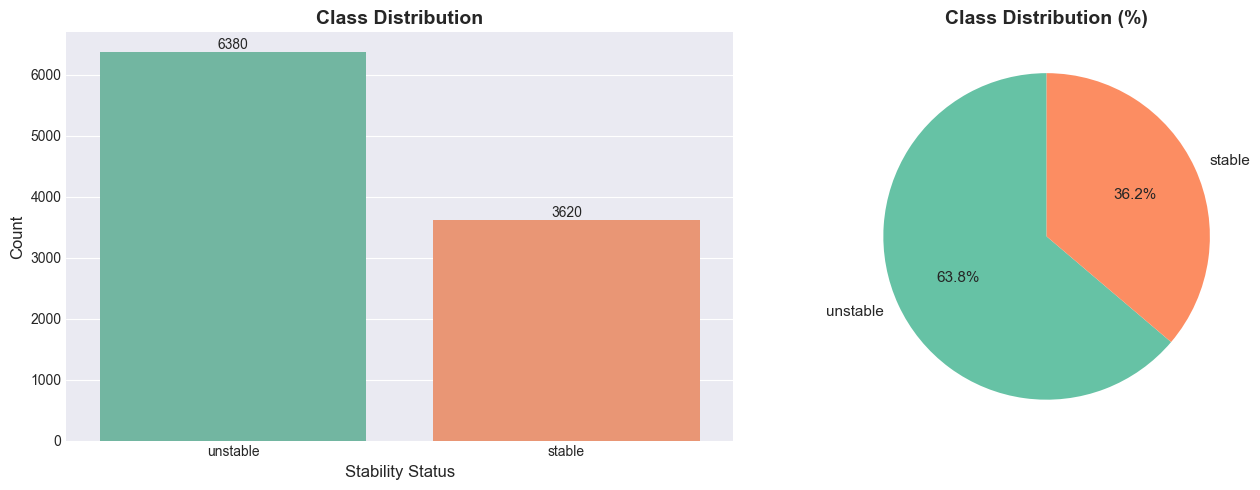

In [5]:
# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='stabf', ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stability Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10)

# Pie chart
class_counts = df['stabf'].value_counts()
colors = sns.color_palette('Set2', len(class_counts))
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/figure_1_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

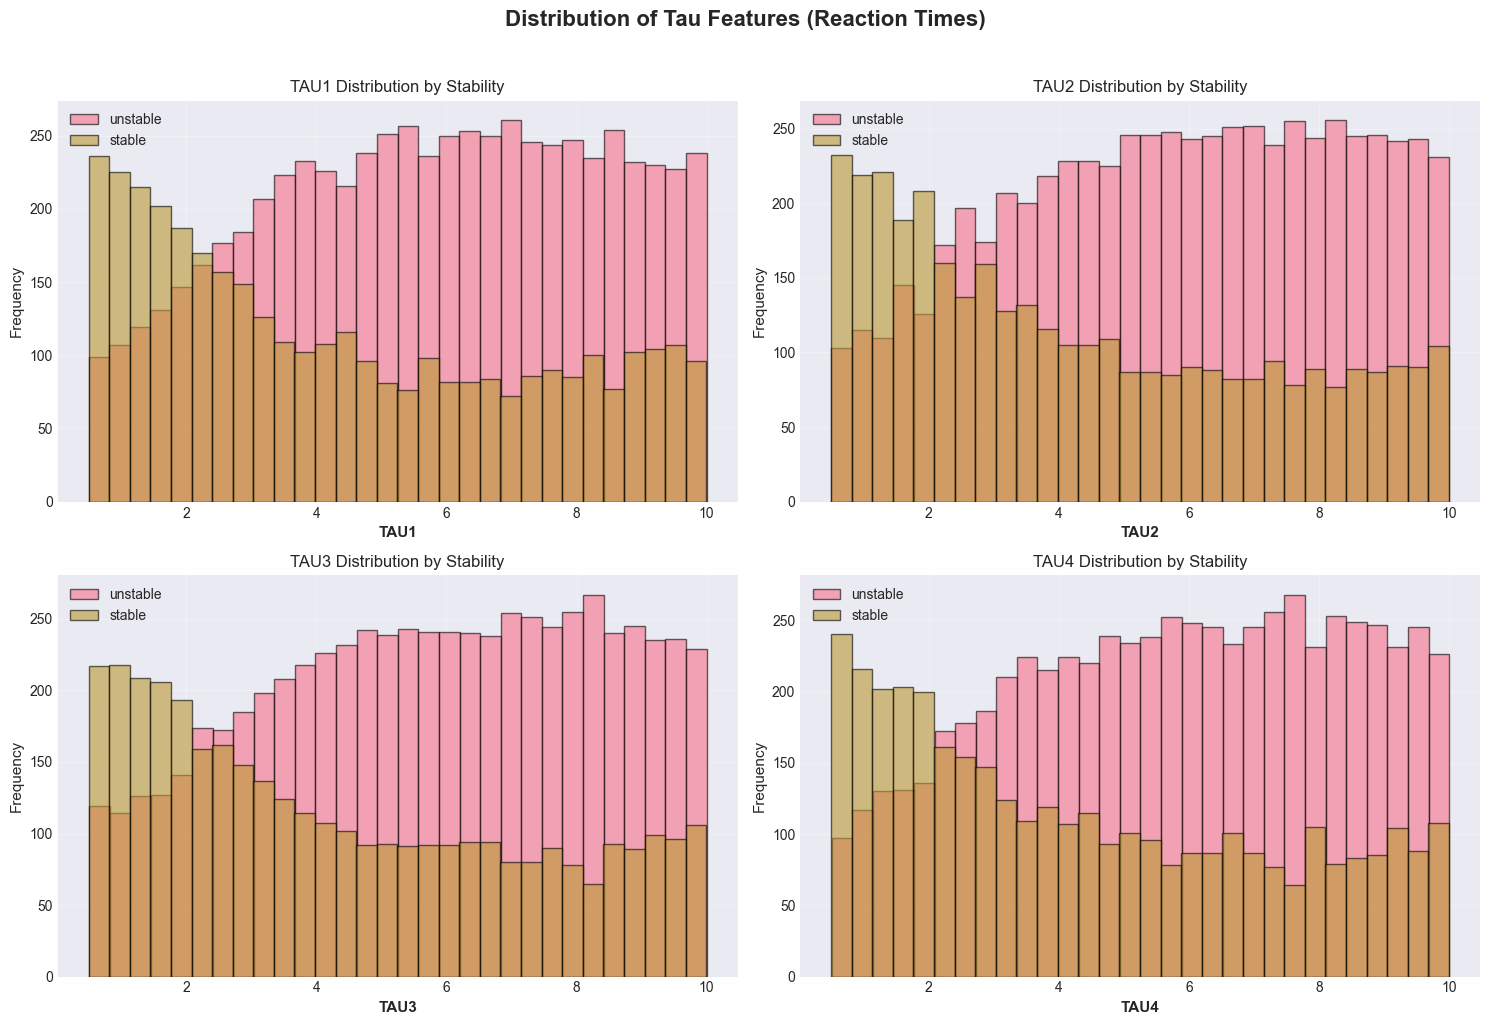

In [6]:
# Distribution of key features (tau variables)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Tau Features (Reaction Times)', fontsize=16, fontweight='bold', y=1.02)

tau_features = ['tau1', 'tau2', 'tau3', 'tau4']
axes = axes.ravel()

for idx, feature in enumerate(tau_features):
    for stability in df['stabf'].unique():
        data = df[df['stabf'] == stability][feature]
        axes[idx].hist(data, alpha=0.6, label=stability, bins=30, edgecolor='black')
    
    axes[idx].set_xlabel(feature.upper(), fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'{feature.upper()} Distribution by Stability', fontsize=12)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/figure_2_tau_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

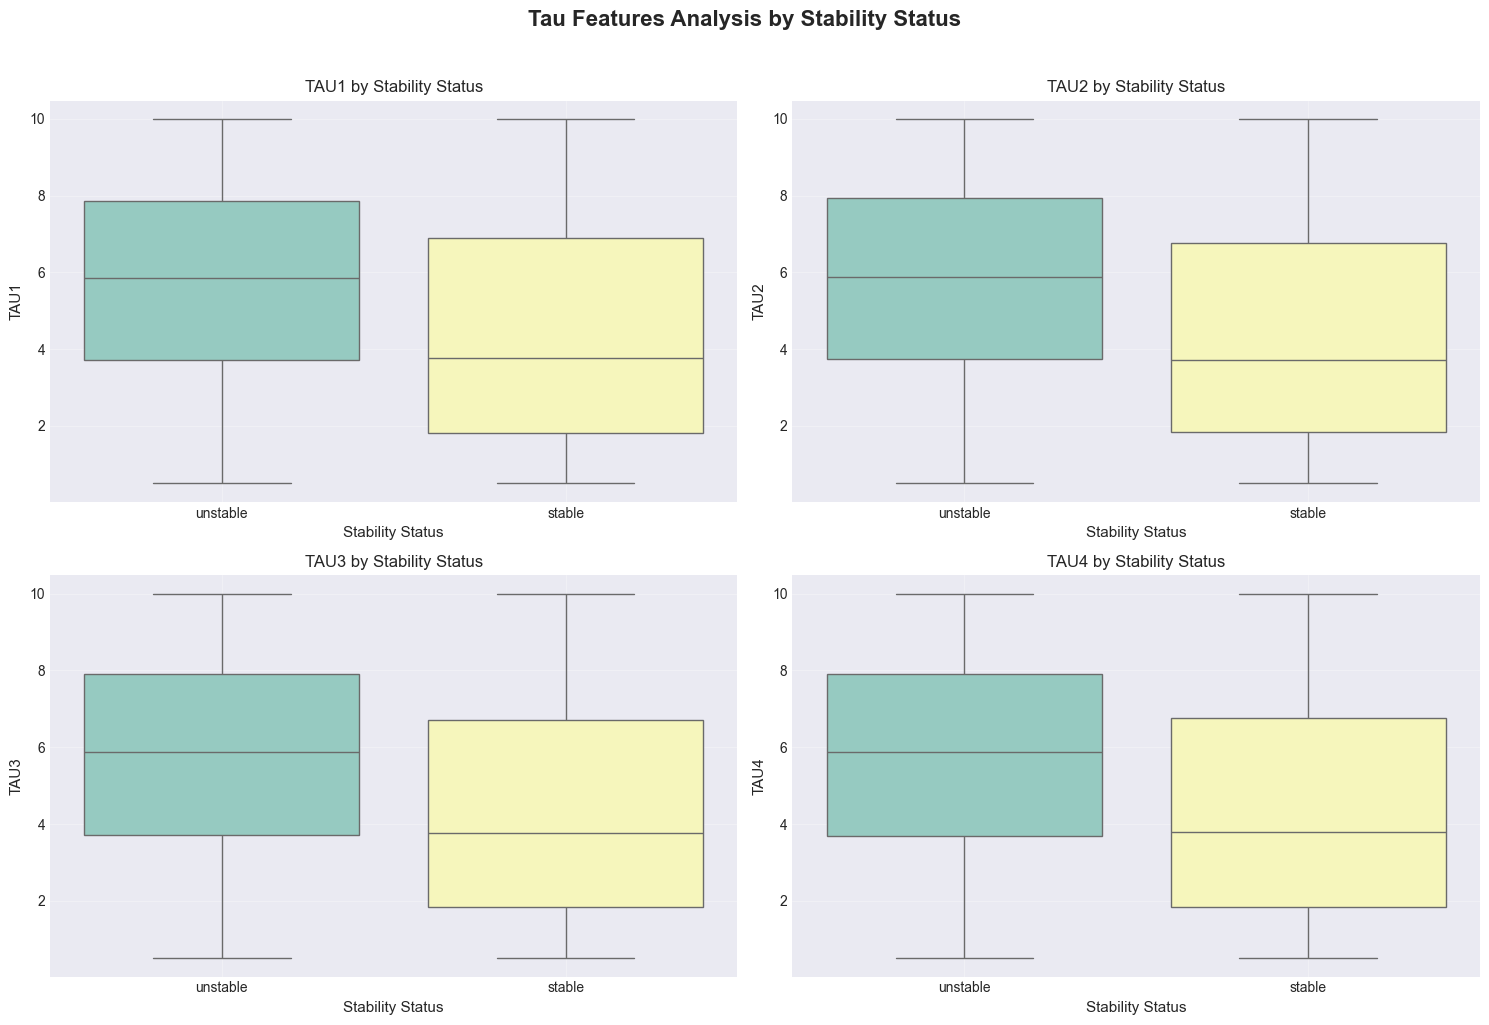

In [7]:
# Box plots for tau features by stability class
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Tau Features Analysis by Stability Status', fontsize=16, fontweight='bold', y=1.02)

axes = axes.ravel()

for idx, feature in enumerate(tau_features):
    sns.boxplot(data=df, x='stabf', y=feature, ax=axes[idx], palette='Set3')
    axes[idx].set_title(f'{feature.upper()} by Stability Status', fontsize=12)
    axes[idx].set_xlabel('Stability Status', fontsize=11)
    axes[idx].set_ylabel(feature.upper(), fontsize=11)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/figure_3_tau_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

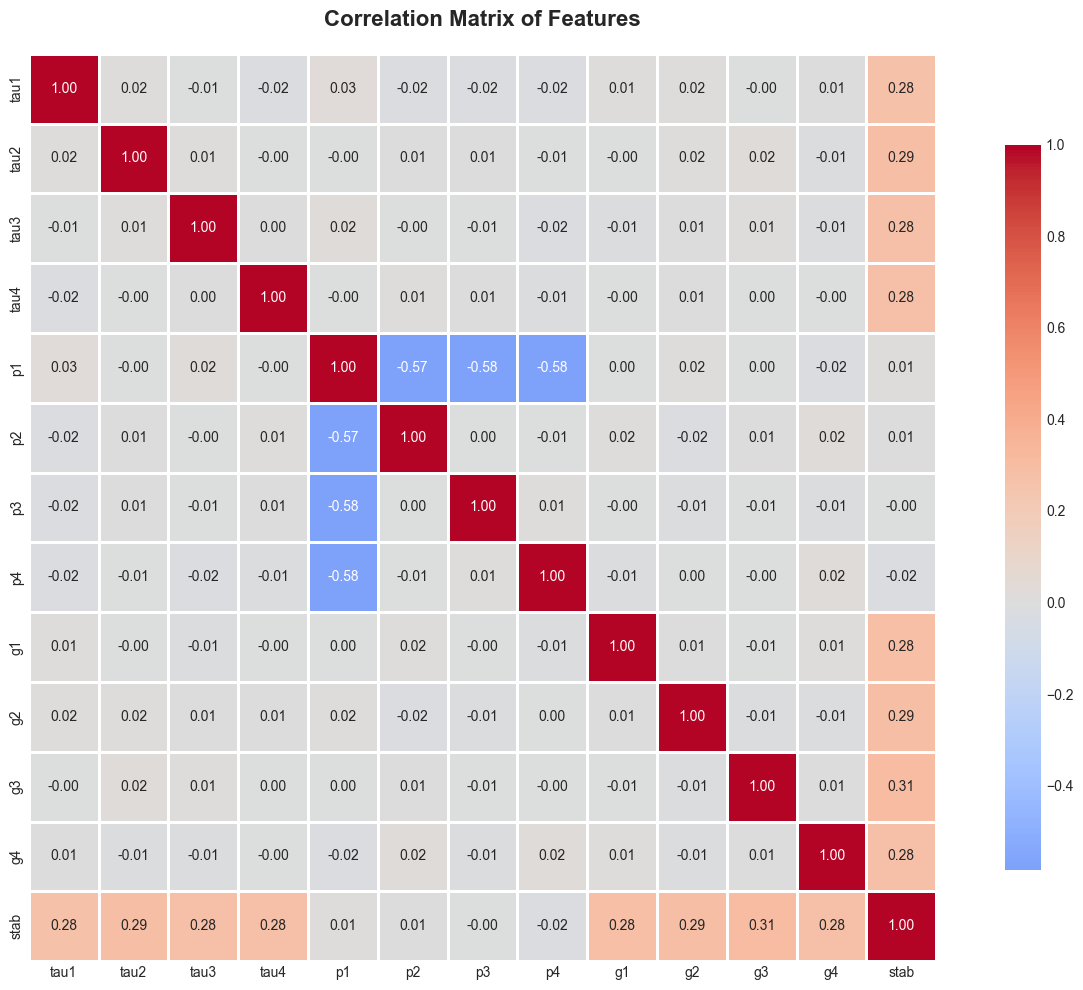

In [8]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('images/figure_4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

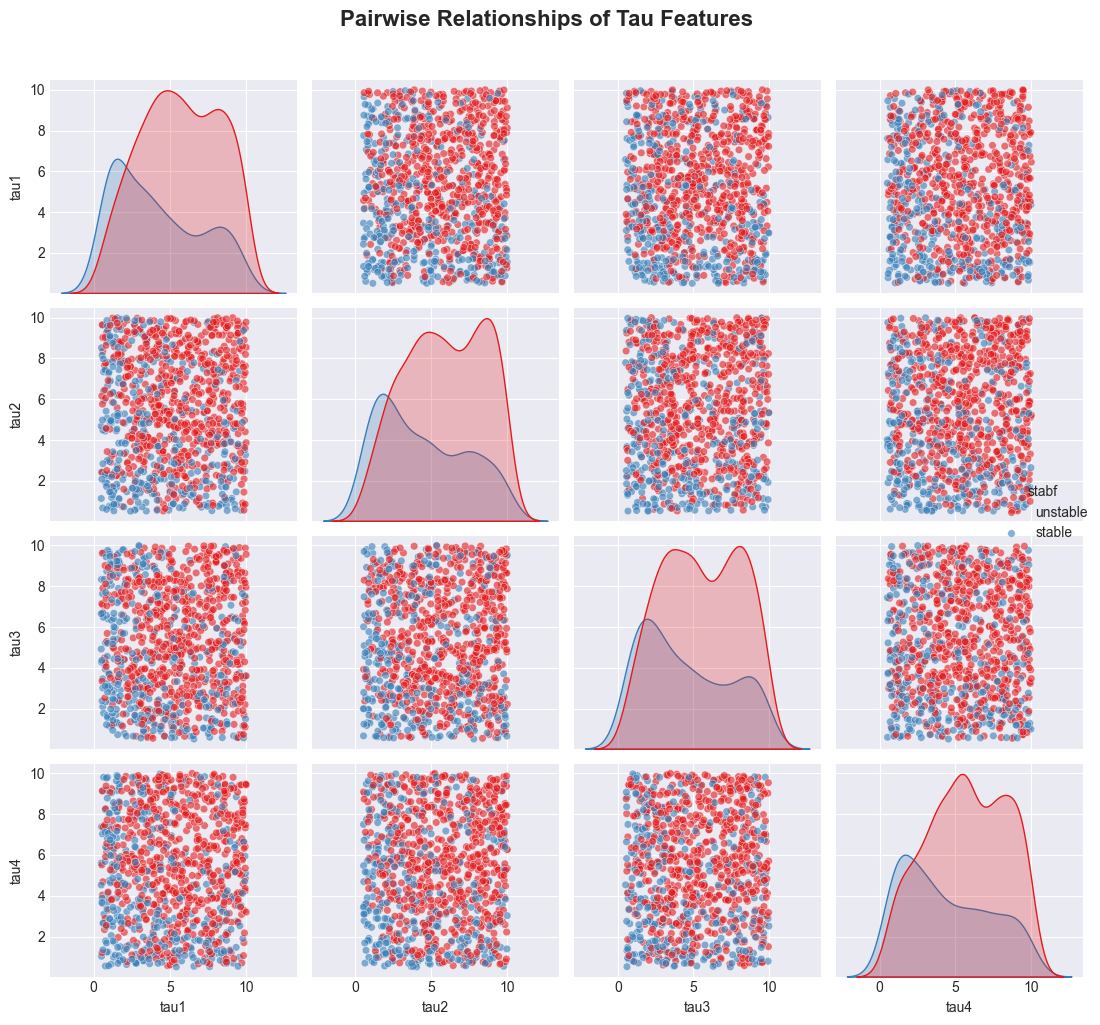

In [9]:
# Pair plot for tau features (sample data for performance)
sample_df = df.sample(n=min(1000, len(df)), random_state=42)
tau_df = sample_df[tau_features + ['stabf']]

pairplot = sns.pairplot(tau_df, hue='stabf', palette='Set1', 
                        plot_kws={'alpha': 0.6, 's': 30}, 
                        diag_kind='kde')
pairplot.fig.suptitle('Pairwise Relationships of Tau Features', 
                      fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/figure_5_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [10]:
# Separate features and target
X = df.drop(['stabf', 'stab'], axis=1)  # Drop both target columns
y = df['stabf']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Features shape: (10000, 12)
Target shape: (10000,)

Features:
['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']


In [11]:
# Encode target variable: stable -> 0, unstable -> 1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original classes:", label_encoder.classes_)
print("Encoding: stable -> 0, unstable -> 1")
print("\nEncoded target distribution:")
print(pd.Series(y_encoded).value_counts().sort_index())

Original classes: ['stable' 'unstable']
Encoding: stable -> 0, unstable -> 1

Encoded target distribution:
0    3620
1    6380
Name: count, dtype: int64


In [12]:
# Split data into training and testing sets (80-20 split with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nTesting set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training set size: (8000, 12)
Testing set size: (2000, 12)

Training set class distribution:
0    2896
1    5104
Name: count, dtype: int64

Testing set class distribution:
0     724
1    1276
Name: count, dtype: int64


In [13]:
# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create DataFrames for easier visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✓ Features scaled successfully!")
print("\nScaled training data sample:")
print(X_train_scaled_df.head())

✓ Features scaled successfully!

Scaled training data sample:
     tau1    tau2    tau3    tau4      p1      p2      p3      p4      g1  \
0 -0.1078 -0.2557 -0.3369  0.2804  1.4837 -1.4120 -1.6544  0.4776  1.0357   
1  0.2233  0.5081  1.5660 -0.4407 -0.6902  1.4280 -0.7621  0.5400 -0.2369   
2  1.6241 -1.3357  1.7068 -0.6432 -0.0758 -0.2563 -0.3745  0.7608  1.2232   
3  1.3919  1.6817  1.2139 -0.8159  0.0061 -1.1642 -0.0667  1.2146  1.3302   
4 -0.9396  0.6009 -1.2858 -0.2930  0.8417 -0.1345 -0.6956 -0.6350  1.3109   

       g2      g3      g4  
0 -0.7189 -1.1048  1.3986  
1  0.2605 -1.4595 -0.2137  
2  0.8011 -0.6066  0.3289  
3  0.3789 -0.6504 -0.7063  
4 -1.4495 -0.3474  0.3861  


## 5. Model Training: Random Forest

In [14]:
# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Training Random Forest Classifier...")
print("="*80)

# Train the model
rf_classifier.fit(X_train, y_train)

print("✓ Random Forest training completed!")
print("\nModel Parameters:")
print(rf_classifier.get_params())

Training Random Forest Classifier...
✓ Random Forest training completed!

Model Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [15]:
# Make predictions with Random Forest
y_train_pred_rf = rf_classifier.predict(X_train)
y_test_pred_rf = rf_classifier.predict(X_test)
y_test_pred_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]

print("✓ Random Forest predictions generated!")

✓ Random Forest predictions generated!


## 6. Model Training: Support Vector Machine (SVM)

In [16]:
# Initialize SVM Classifier with RBF kernel
svm_classifier = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42,
    verbose=False
)

print("Training SVM Classifier with RBF kernel...")
print("="*80)

# Train the model (using scaled data)
svm_classifier.fit(X_train_scaled, y_train)

print("✓ SVM training completed!")
print("\nModel Parameters:")
print(svm_classifier.get_params())

Training SVM Classifier with RBF kernel...
✓ SVM training completed!

Model Parameters:
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [17]:
# Make predictions with SVM
y_train_pred_svm = svm_classifier.predict(X_train_scaled)
y_test_pred_svm = svm_classifier.predict(X_test_scaled)
y_test_pred_proba_svm = svm_classifier.predict_proba(X_test_scaled)[:, 1]

print("✓ SVM predictions generated!")

✓ SVM predictions generated!


## 7. Model Evaluation

In [18]:
# Function to calculate all metrics
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Calculate and display comprehensive evaluation metrics
    """
    print(f"\n{'='*80}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*80}")
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    print(f"\n{'-'*80}")
    print("Classification Report:")
    print(f"{'-'*80}")
    print(classification_report(y_true, y_pred, 
                                target_names=['Stable', 'Unstable'],
                                digits=4))
    
    # Return metrics as dictionary
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

In [19]:
# Evaluate Random Forest
rf_metrics = evaluate_model(y_test, y_test_pred_rf, y_test_pred_proba_rf, 
                            "Random Forest")


Random Forest - Performance Metrics
Accuracy:  0.9240 (92.40%)
Precision: 0.9226 (92.26%)
Recall:    0.9616 (96.16%)
F1-Score:  0.9417
ROC-AUC:   0.9806

--------------------------------------------------------------------------------
Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Stable     0.9269    0.8577    0.8910       724
    Unstable     0.9226    0.9616    0.9417      1276

    accuracy                         0.9240      2000
   macro avg     0.9247    0.9097    0.9163      2000
weighted avg     0.9241    0.9240    0.9233      2000



In [20]:
# Evaluate SVM
svm_metrics = evaluate_model(y_test, y_test_pred_svm, y_test_pred_proba_svm, 
                             "Support Vector Machine (SVM)")


Support Vector Machine (SVM) - Performance Metrics
Accuracy:  0.9635 (96.35%)
Precision: 0.9666 (96.66%)
Recall:    0.9765 (97.65%)
F1-Score:  0.9715
ROC-AUC:   0.9949

--------------------------------------------------------------------------------
Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Stable     0.9578    0.9406    0.9491       724
    Unstable     0.9666    0.9765    0.9715      1276

    accuracy                         0.9635      2000
   macro avg     0.9622    0.9585    0.9603      2000
weighted avg     0.9634    0.9635    0.9634      2000



In [21]:
# Compare models side-by-side
comparison_df = pd.DataFrame([rf_metrics, svm_metrics])
comparison_df = comparison_df.set_index('Model')

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df)

# Determine better model
print("\n" + "="*80)
print("WINNER BY METRIC:")
print("="*80)
for col in comparison_df.columns:
    winner = comparison_df[col].idxmax()
    winner_value = comparison_df[col].max()
    print(f"{col:<15} : {winner} ({winner_value:.4f})")


MODEL COMPARISON
                              Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                       
Random Forest                   0.9240     0.9226  0.9616    0.9417   0.9806
Support Vector Machine (SVM)    0.9635     0.9666  0.9765    0.9715   0.9949

WINNER BY METRIC:
Accuracy        : Support Vector Machine (SVM) (0.9635)
Precision       : Support Vector Machine (SVM) (0.9666)
Recall          : Support Vector Machine (SVM) (0.9765)
F1-Score        : Support Vector Machine (SVM) (0.9715)
ROC-AUC         : Support Vector Machine (SVM) (0.9949)


## 8. Confusion Matrices

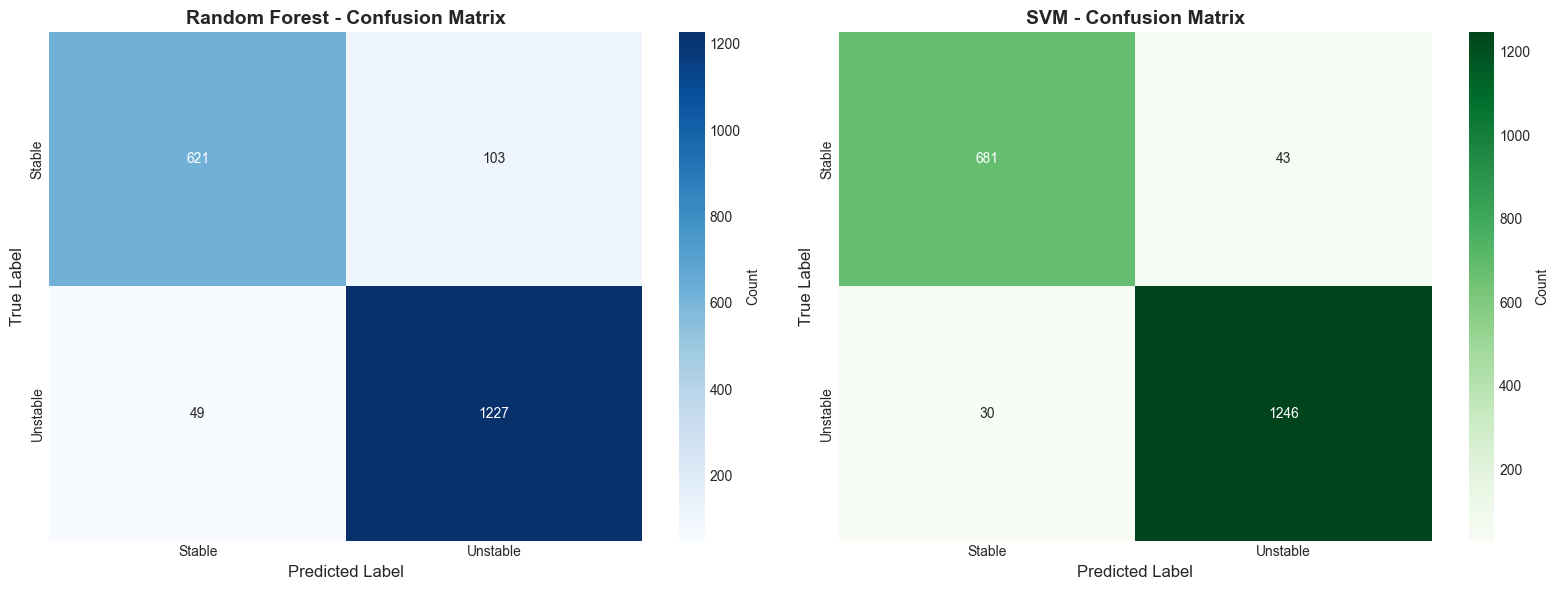

In [22]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable', 'Unstable'],
            yticklabels=['Stable', 'Unstable'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Stable', 'Unstable'],
            yticklabels=['Stable', 'Unstable'],
            cbar_kws={'label': 'Count'})
axes[1].set_title('SVM - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('images/figure_6_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. ROC Curves

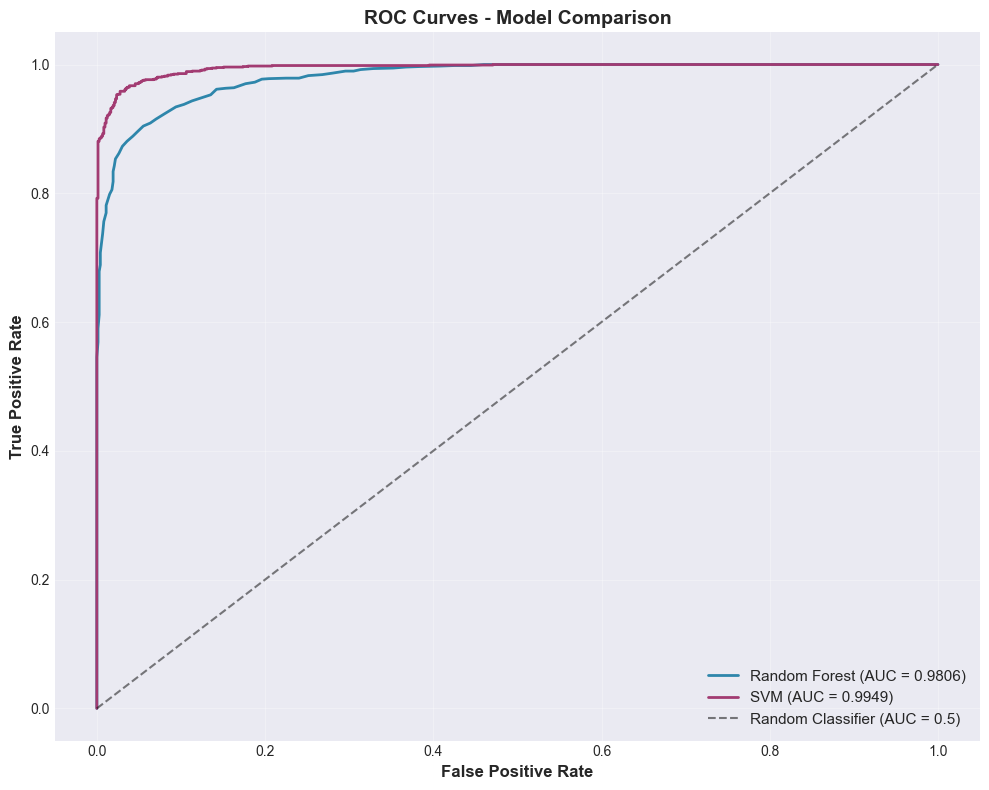

In [23]:
# Calculate ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_pred_proba_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_test_pred_proba_svm)

roc_auc_rf = roc_auc_score(y_test, y_test_pred_proba_rf)
roc_auc_svm = roc_auc_score(y_test, y_test_pred_proba_svm)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', 
         linewidth=2, color='#2E86AB')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.4f})', 
         linewidth=2, color='#A23B72')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', 
         linewidth=1.5, alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/figure_7_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Precision-Recall Curves

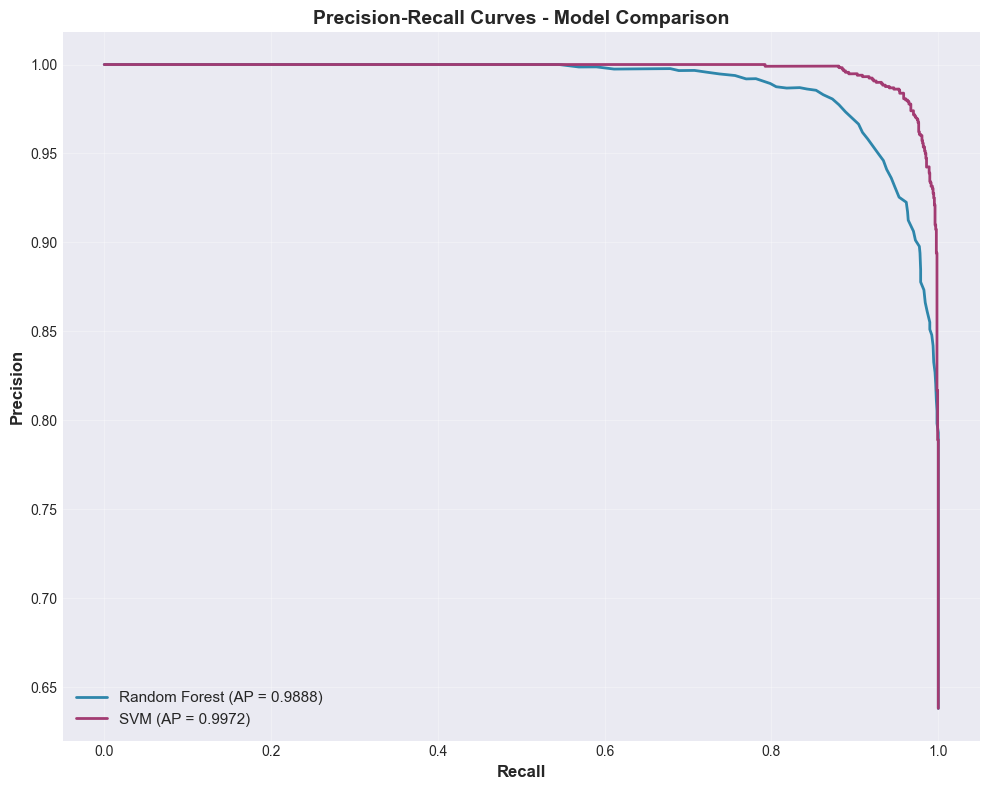

In [24]:
# Calculate Precision-Recall curves
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_test_pred_proba_rf)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_test_pred_proba_svm)

ap_rf = average_precision_score(y_test, y_test_pred_proba_rf)
ap_svm = average_precision_score(y_test, y_test_pred_proba_svm)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.4f})', 
         linewidth=2, color='#2E86AB')
plt.plot(recall_svm, precision_svm, label=f'SVM (AP = {ap_svm:.4f})', 
         linewidth=2, color='#A23B72')

plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/figure_8_precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Feature Importance (Random Forest)

In [25]:
# Extract feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest - Feature Importance:")
print("="*80)
print(feature_importance.to_string(index=False))

Random Forest - Feature Importance:
Feature  Importance
   tau2      0.1247
   tau3      0.1229
   tau1      0.1211
   tau4      0.1199
     g3      0.1035
     g1      0.0979
     g2      0.0964
     g4      0.0957
     p4      0.0304
     p2      0.0298
     p3      0.0290
     p1      0.0289


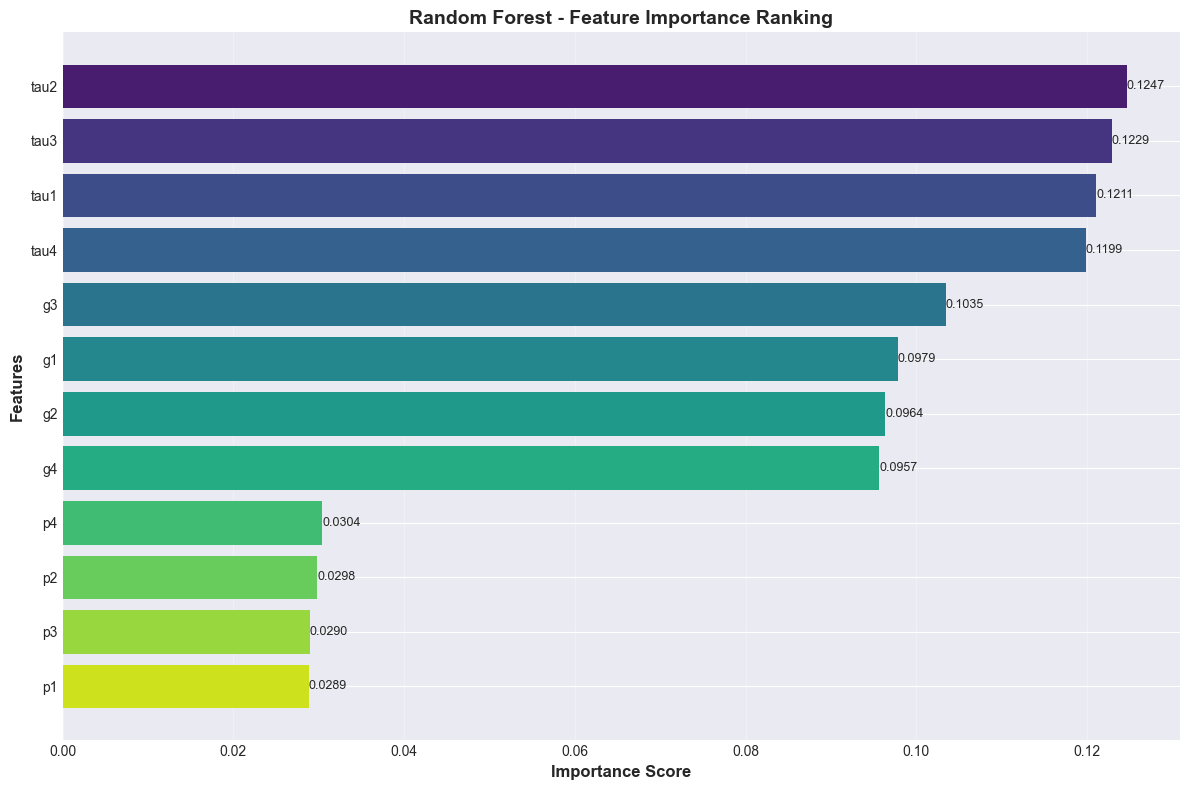

In [26]:
# Visualize feature importance
plt.figure(figsize=(12, 8))
colors = sns.color_palette('viridis', len(feature_importance))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)

plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Random Forest - Feature Importance Ranking', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('images/figure_9_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

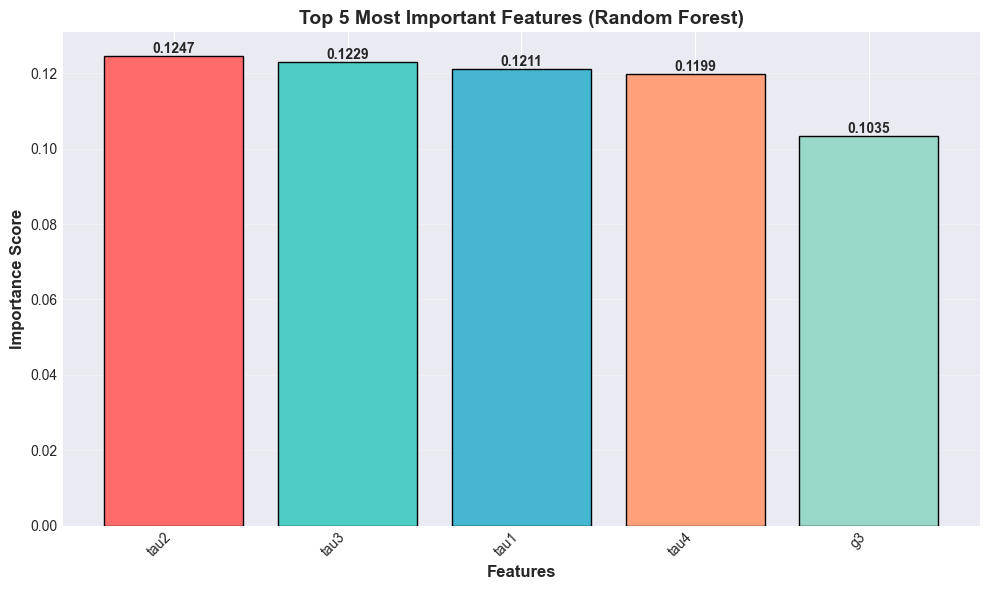

In [27]:
# Top 5 most important features
top_features = feature_importance.head(5)

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
plt.bar(top_features['Feature'], top_features['Importance'], color=colors, edgecolor='black')
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 5 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for i, (feat, imp) in enumerate(zip(top_features['Feature'], top_features['Importance'])):
    plt.text(i, imp, f'{imp:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/figure_10_top5_features.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Cross-Validation Analysis

In [28]:
# Perform 5-fold cross-validation for both models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Performing 5-Fold Cross-Validation...")
print("="*80)

# Random Forest CV
rf_cv_scores = cross_val_score(rf_classifier, X, y_encoded, cv=cv, 
                                scoring='accuracy', n_jobs=-1)
print("\nRandom Forest Cross-Validation Scores:")
print(f"Fold Scores: {rf_cv_scores}")
print(f"Mean Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")

# SVM CV (using scaled data)
X_scaled_full = scaler.fit_transform(X)
svm_cv_scores = cross_val_score(svm_classifier, X_scaled_full, y_encoded, cv=cv, 
                                 scoring='accuracy', n_jobs=-1)
print("\nSVM Cross-Validation Scores:")
print(f"Fold Scores: {svm_cv_scores}")
print(f"Mean Accuracy: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})")

Performing 5-Fold Cross-Validation...

Random Forest Cross-Validation Scores:
Fold Scores: [0.9165 0.9125 0.92   0.9245 0.9185]
Mean Accuracy: 0.9184 (+/- 0.0079)

SVM Cross-Validation Scores:
Fold Scores: [0.954  0.9565 0.954  0.9595 0.958 ]
Mean Accuracy: 0.9564 (+/- 0.0044)


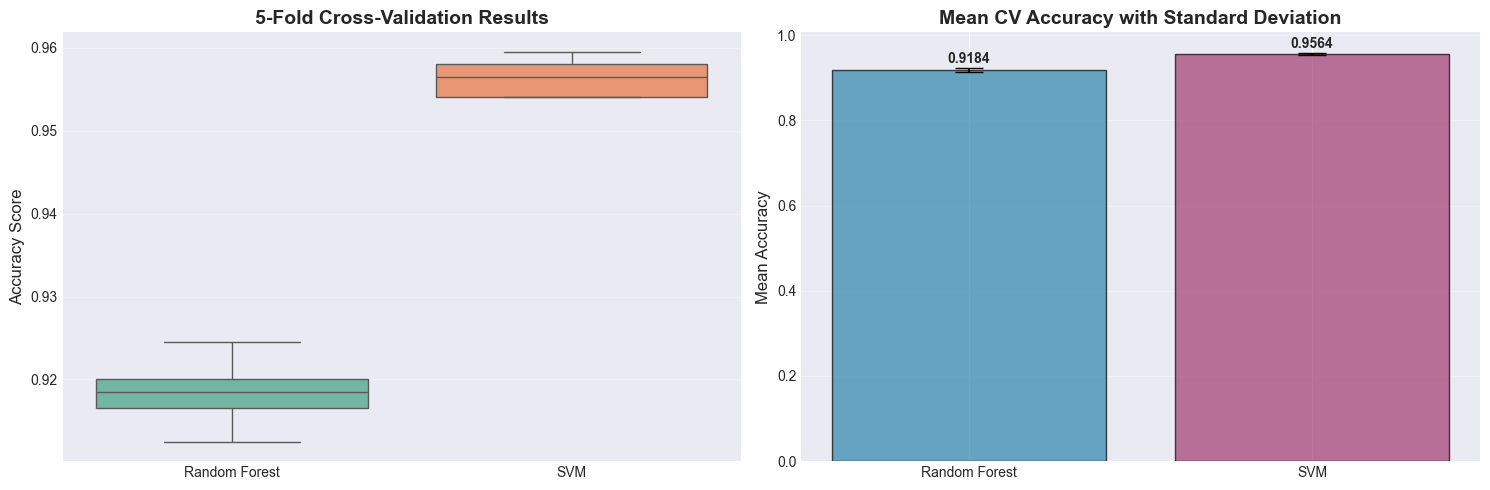

In [29]:
# Visualize cross-validation results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
cv_data = pd.DataFrame({
    'Random Forest': rf_cv_scores,
    'SVM': svm_cv_scores
})

sns.boxplot(data=cv_data, ax=axes[0], palette='Set2')
axes[0].set_ylabel('Accuracy Score', fontsize=12)
axes[0].set_title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Bar plot with error bars
models = ['Random Forest', 'SVM']
means = [rf_cv_scores.mean(), svm_cv_scores.mean()]
stds = [rf_cv_scores.std(), svm_cv_scores.std()]

x_pos = np.arange(len(models))
bars = axes[1].bar(x_pos, means, yerr=stds, capsize=10, 
                   color=['#2E86AB', '#A23B72'], edgecolor='black', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Mean Accuracy', fontsize=12)
axes[1].set_title('Mean CV Accuracy with Standard Deviation', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (mean, std) in enumerate(zip(means, stds)):
    axes[1].text(i, mean + std + 0.005, f'{mean:.4f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('images/figure_11_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Model Performance Summary

In [30]:
# Create comprehensive performance summary
summary_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV Mean', 'CV Std'],
    'Random Forest': [
        rf_metrics['Accuracy'],
        rf_metrics['Precision'],
        rf_metrics['Recall'],
        rf_metrics['F1-Score'],
        rf_metrics['ROC-AUC'],
        rf_cv_scores.mean(),
        rf_cv_scores.std()
    ],
    'SVM': [
        svm_metrics['Accuracy'],
        svm_metrics['Precision'],
        svm_metrics['Recall'],
        svm_metrics['F1-Score'],
        svm_metrics['ROC-AUC'],
        svm_cv_scores.mean(),
        svm_cv_scores.std()
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("COMPREHENSIVE MODEL PERFORMANCE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

# Calculate differences
summary_df['Difference (RF - SVM)'] = summary_df['Random Forest'] - summary_df['SVM']
print("\n" + "="*80)
print("PERFORMANCE DIFFERENCES")
print("="*80)
print(summary_df.to_string(index=False))


COMPREHENSIVE MODEL PERFORMANCE SUMMARY
   Metric  Random Forest    SVM
 Accuracy         0.9240 0.9635
Precision         0.9226 0.9666
   Recall         0.9616 0.9765
 F1-Score         0.9417 0.9715
  ROC-AUC         0.9806 0.9949
  CV Mean         0.9184 0.9564
   CV Std         0.0040 0.0022

PERFORMANCE DIFFERENCES
   Metric  Random Forest    SVM  Difference (RF - SVM)
 Accuracy         0.9240 0.9635                -0.0395
Precision         0.9226 0.9666                -0.0441
   Recall         0.9616 0.9765                -0.0149
 F1-Score         0.9417 0.9715                -0.0299
  ROC-AUC         0.9806 0.9949                -0.0142
  CV Mean         0.9184 0.9564                -0.0380
   CV Std         0.0040 0.0022                 0.0018


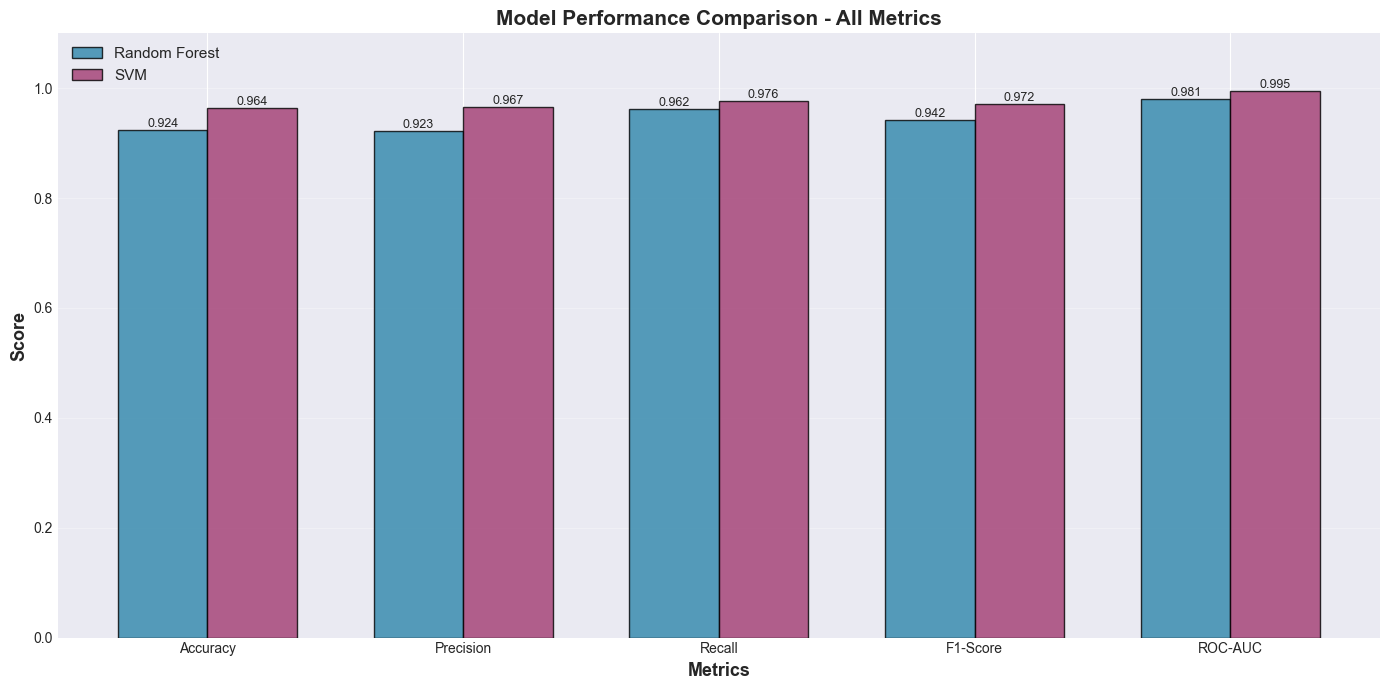

In [31]:
# Visualize all metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
rf_values = [rf_metrics[m] for m in metrics]
svm_values = [svm_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', 
               color='#2E86AB', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, svm_values, width, label='SVM', 
               color='#A23B72', edgecolor='black', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Model Performance Comparison - All Metrics', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars1)
add_value_labels(bars2)

plt.tight_layout()
plt.savefig('images/figure_12_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Final Recommendations

In [32]:
print("\n" + "="*80)
print("FINAL RECOMMENDATIONS")
print("="*80)

# Determine the best model
if rf_metrics['ROC-AUC'] > svm_metrics['ROC-AUC']:
    best_model = "Random Forest"
    best_auc = rf_metrics['ROC-AUC']
else:
    best_model = "Support Vector Machine (SVM)"
    best_auc = svm_metrics['ROC-AUC']

print(f"\n✓ Recommended Model: {best_model}")
print(f"  ROC-AUC Score: {best_auc:.4f}")

print("\n" + "-"*80)
print("KEY FINDINGS:")
print("-"*80)

print("\n1. MODEL PERFORMANCE:")
print(f"   • Random Forest achieved {rf_metrics['Accuracy']*100:.2f}% accuracy")
print(f"   • SVM achieved {svm_metrics['Accuracy']*100:.2f}% accuracy")
print(f"   • Both models show {(min(rf_metrics['ROC-AUC'], svm_metrics['ROC-AUC'])*100):.2f}%+ ROC-AUC scores")

print("\n2. FEATURE IMPORTANCE:")
print("   • Top 3 features (from Random Forest):")
for i, row in feature_importance.head(3).iterrows():
    print(f"     {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n3. CROSS-VALIDATION:")
print(f"   • Random Forest CV: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")
print(f"   • SVM CV: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std():.4f})")

print("\n4. PRACTICAL CONSIDERATIONS:")
print("   • For SAFETY (high recall): Choose the model with better recall")
print("   • For EFFICIENCY (low false alarms): Choose the model with better precision")
print("   • For INTERPRETABILITY: Random Forest provides feature importance")
print("   • For TIGHT BOUNDARIES: SVM with RBF kernel is effective")

print("\n" + "="*80)
print("✓ Analysis Complete!")
print("="*80)


FINAL RECOMMENDATIONS

✓ Recommended Model: Support Vector Machine (SVM)
  ROC-AUC Score: 0.9949

--------------------------------------------------------------------------------
KEY FINDINGS:
--------------------------------------------------------------------------------

1. MODEL PERFORMANCE:
   • Random Forest achieved 92.40% accuracy
   • SVM achieved 96.35% accuracy
   • Both models show 98.06%+ ROC-AUC scores

2. FEATURE IMPORTANCE:
   • Top 3 features (from Random Forest):
     2. tau2: 0.1247
     3. tau3: 0.1229
     1. tau1: 0.1211

3. CROSS-VALIDATION:
   • Random Forest CV: 0.9184 (+/- 0.0040)
   • SVM CV: 0.9564 (+/- 0.0022)

4. PRACTICAL CONSIDERATIONS:
   • For SAFETY (high recall): Choose the model with better recall
   • For EFFICIENCY (low false alarms): Choose the model with better precision
   • For INTERPRETABILITY: Random Forest provides feature importance
   • For TIGHT BOUNDARIES: SVM with RBF kernel is effective

✓ Analysis Complete!


## 15. Save Models (Optional)

In [33]:
# Uncomment to save models
# import joblib

# # Save Random Forest model
# joblib.dump(rf_classifier, 'random_forest_model.pkl')
# print("✓ Random Forest model saved as 'random_forest_model.pkl'")

# # Save SVM model
# joblib.dump(svm_classifier, 'svm_model.pkl')
# print("✓ SVM model saved as 'svm_model.pkl'")

# # Save scaler
# joblib.dump(scaler, 'scaler.pkl')
# print("✓ Scaler saved as 'scaler.pkl'")

print("Note: Uncomment the code above to save the trained models.")

Note: Uncomment the code above to save the trained models.


---

## Summary

This notebook demonstrates:
1. **Data Loading & Exploration**: Understanding the electric power grid stability dataset
2. **Preprocessing**: Encoding labels, scaling features, and splitting data
3. **Model Training**: Implementing Random Forest and SVM classifiers
4. **Evaluation**: Comprehensive metrics including accuracy, precision, recall, F1, ROC-AUC
5. **Visualization**: Confusion matrices, ROC curves, feature importance, and more
6. **Cross-Validation**: Ensuring model consistency across different data splits
7. **Comparison**: Side-by-side analysis of both models

**Key Takeaways:**
- Both Random Forest and SVM are effective for power grid stability prediction
- Random Forest provides interpretability through feature importance
- SVM excels at finding clear decision boundaries
- Tau features (reaction times) are the most important predictors
- Cross-validation confirms model consistency

---